In [ ]:
#| default_exp clustering_analysis

# Libraries

In [ ]:
from numba import float64, int64,  njit, prange

import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from tqdm.auto import tqdm

import os, socket

# Radial distribution function

In [ ]:
"""
Pair correlation function g(r) and related spatial statistics
for 2D foraging simulations with small N.

Main function: compute_gr()
Bonus:         clark_evans_index()  (scalar aggregation metric)
"""



def compute_gr(
    positions_list: list,
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    periodic: bool = True,
) -> tuple:
    """
    Compute the radial distribution function g(r) for a 2D square box,
    accumulated over many frames (time steps and/or episodes).

    g(r) = 1 means random (ideal gas). g(r) > 1 at small r means aggregation.

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
        One array per frame (time step or episode snapshot).
        N may vary between frames if agents enter/leave, but is
        typically fixed at N_a.
    L : float
        Side length of the square box.
    dr : float
        Bin width for r (same units as positions and L).
    r_max : float or None
        Maximum r to compute. Defaults to L/2, which is the safe
        limit for periodic boundary conditions to avoid shells
        that wrap around and double-count pairs.
    periodic : bool
        If True  -> periodic boundary conditions (torus), standard for
                    physics simulations.
        If False -> hard-wall box. A simple edge correction is applied
                    (fraction of the shell circle that falls inside the box),
                    which works well for r << L but is approximate near r_max.

    Returns
    -------
    r_centers : np.ndarray, shape (n_bins,)
        Bin centre positions.
    gr : np.ndarray, shape (n_bins,)
        g(r) values, normalised so that g(r) -> 1 for large r.
    counts : np.ndarray, shape (n_bins,)
        Raw pair counts per bin (useful for diagnosing empty bins at large r).
    """
    if r_max is None:
        r_max = L / 2.0

    n_bins = int(r_max / dr)
    r_edges = np.linspace(0, r_max, n_bins + 1)
    r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])

    hist_accum = np.zeros(n_bins, dtype=np.float64)
    # Track per-frame N and correction factor separately
    norm_accum = np.zeros(n_bins, dtype=np.float64)

    n_frames = 0

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue
        n_frames += 1

        # ----------------------------------------------------------------
        # Pairwise distances (vectorised, fine for N=50)
        # ----------------------------------------------------------------
        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]  # (N,N,2)

        if periodic:
            # Minimum image convention
            diff -= L * np.round(diff / L)
        # else: raw Cartesian differences (box assumed to be [0, L] x [0, L])

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))  # (N, N)

        # Only upper triangle (i < j) to count each pair once
        i_idx, j_idx = np.triu_indices(N, k=1)
        r_pairs = r_matrix[i_idx, j_idx]

        # Histogram of pair distances for this frame
        h, _ = np.histogram(r_pairs, bins=r_edges)
        hist_accum += h

        # ----------------------------------------------------------------
        # Expected counts for an ideal gas (normalisation denominator)
        # ----------------------------------------------------------------
        area = L ** 2
        n_pairs = N * (N - 1) / 2  # unordered pairs

        if periodic:
            # Shell is always a full annulus
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas / area
        else:
            # Edge correction: for each shell, estimate the fraction of the
            # annulus that lies inside the [0,L]x[0,L] box.
            # This uses the mean-centre approximation (exact for a random
            # uniform centre averaged over the box).
            frac = _edge_correction(r_centers, dr, L)
            shell_areas = 2 * np.pi * r_centers * dr
            expected = n_pairs * shell_areas * frac / area

        norm_accum += expected

    if n_frames == 0:
        raise ValueError("No valid frames found (need at least 2 agents per frame).")

    # g(r) = observed / expected, both accumulated over all frames
    # Avoid division by zero for bins with no expected counts
    with np.errstate(invalid="ignore", divide="ignore"):
        gr = np.where(norm_accum > 0, hist_accum / norm_accum, 0.0)

    return r_centers, gr, hist_accum


@njit(cache=True)
def _edge_correction_numba(r_centers: np.ndarray, L: float) -> np.ndarray:
    frac = np.empty_like(r_centers)
    half_L = L / 2.0
    base = np.pi * L

    for idx in range(r_centers.shape[0]):
        r = r_centers[idx]
        value = 1.0 - (2.0 * r) / base

        if r < half_L:
            if value < 0.0:
                value = 0.0
            frac[idx] = value
        else:
            if value < 0.05:
                value = 0.05
            elif value > 1.0:
                value = 1.0
            frac[idx] = value

    return frac


@njit(cache=True)
def _compute_gr_numba_kernel(
    positions_array: np.ndarray,
    L: float,
    dr: float,
    r_max: float,
    periodic: bool = True
):
    n_frames, n_agents, _ = positions_array.shape
    n_bins = int(r_max / dr)

    r_centers = np.empty(n_bins, dtype=np.float64)
    for b in range(n_bins):
        r_centers[b] = (b + 0.5) * dr

    hist_accum = np.zeros(n_bins, dtype=np.float64)
    norm_accum = np.zeros(n_bins, dtype=np.float64)

    area = L * L
    n_pairs = n_agents * (n_agents - 1) / 2.0

    if periodic:
        frac = np.ones(n_bins, dtype=np.float64)
    else:
        frac = _edge_correction_numba(r_centers, L)

    for f in range(n_frames):
        # Pairwise distances without allocating an NxN distance matrix.
        for i in range(n_agents - 1):
            xi = positions_array[f, i, 0]
            yi = positions_array[f, i, 1]
            for j in range(i + 1, n_agents):
                dx = xi - positions_array[f, j, 0]
                dy = yi - positions_array[f, j, 1]

                if periodic:
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)

                r = np.sqrt(dx * dx + dy * dy)
                idx_bin = int(r / dr)
                if 0 <= idx_bin < n_bins:
                    hist_accum[idx_bin] += 1.0

        for b in range(n_bins):
            shell_area = 2.0 * np.pi * r_centers[b] * dr
            norm_accum[b] += n_pairs * shell_area * frac[b] / area

    gr = np.zeros(n_bins, dtype=np.float64)
    for b in range(n_bins):
        if norm_accum[b] > 0.0:
            gr[b] = hist_accum[b] / norm_accum[b]

    return r_centers, gr, hist_accum


def compute_gr_numba(
    positions_list: Union[list, np.ndarray],
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    periodic: bool = True,
) -> tuple:
    """
    Numba-optimized copy of compute_gr().

    Expected input layout is a dense array of shape (n_frames, n_agents, 2).
    This keeps the function in nopython mode and avoids expensive Python loops.
    """
    if r_max is None:
        r_max = L / 2.0

    positions_array = np.asarray(positions_list, dtype=np.float64)
    if positions_array.ndim != 3 or positions_array.shape[2] != 2:
        raise ValueError("positions_list must be convertible to shape (n_frames, n_agents, 2).")

    if positions_array.shape[1] < 2:
        raise ValueError("Need at least 2 agents per frame.")

    return _compute_gr_numba_kernel(positions_array, L, dr, r_max, periodic)


@njit(cache=True)
def _clark_evans_numba_kernel(positions_array: np.ndarray, L: float, periodic: bool = True) -> float:
    """
    Numba kernel for Clark-Evans R averaged over frames.

    positions_array : (n_frames, n_agents, 2)
    """
    n_frames, n_agents, _ = positions_array.shape
    area = L * L
    rho = n_agents / area
    expected_nn = 1.0 / (2.0 * np.sqrt(rho))

    R_sum = 0.0
    for f in range(n_frames):
        mean_nn = 0.0
        for i in range(n_agents):
            min_dist = np.inf
            for j in range(n_agents):
                if i == j:
                    continue
                dx = positions_array[f, i, 0] - positions_array[f, j, 0]
                dy = positions_array[f, i, 1] - positions_array[f, j, 1]
                if periodic:
                    dx -= L * np.round(dx / L)
                    dy -= L * np.round(dy / L)
                dist = np.sqrt(dx * dx + dy * dy)
                if dist < min_dist:
                    min_dist = dist
            mean_nn += min_dist
        mean_nn /= n_agents
        R_sum += mean_nn / expected_nn

    return R_sum / n_frames


@njit(parallel=True, cache=True)
def _compute_gr_clark_evans_all_runs_kernel(
    positions_all: np.ndarray,
    L: float,
    dr: float,
    r_max: float,
    periodic: bool = True,
):
    """
    Compute g(r) and Clark-Evans R for all runs in parallel.

    positions_all : (n_runs, n_frames, n_agents, 2)
    Returns r_centers (n_bins,), grs (n_runs, n_bins), cr_vals (n_runs,)
    """
    n_runs, n_frames, n_agents, _ = positions_all.shape
    n_bins = int(r_max / dr)

    r_centers = np.empty(n_bins, dtype=np.float64)
    for b in range(n_bins):
        r_centers[b] = (b + 0.5) * dr

    grs = np.zeros((n_runs, n_bins), dtype=np.float64)
    cr_vals = np.zeros(n_runs, dtype=np.float64)

    for run in prange(n_runs):
        _, gr_run, _ = _compute_gr_numba_kernel(positions_all[run], L, dr, r_max, periodic)
        grs[run] = gr_run
        cr_vals[run] = _clark_evans_numba_kernel(positions_all[run], L, periodic)

    return r_centers, grs, cr_vals


def compute_gr_all_runs(
    posr: np.ndarray,
    L: float,
    dr: float = 0.5,
    r_max: float = None,
    episode: int = 0,
    periodic: bool = True,
) -> tuple:
    """
    Compute g(r) and Clark-Evans R for all runs in parallel.

    Parameters
    ----------
    posr : np.ndarray, shape (n_runs, n_episodes, n_frames, n_agents, 2)
    L : float
    dr : float
    r_max : float or None
    episode : int
        Episode index to select (default 0).
    periodic : bool

    Returns
    -------
    r_centers : np.ndarray (n_bins,)
    grs : np.ndarray (n_runs, n_bins)
    cr_vals : np.ndarray (n_runs,)
    """
    if r_max is None:
        r_max = L / 2.0

    # Select the desired episode across all runs: (n_runs, n_frames, n_agents, 2)
    positions_all = np.ascontiguousarray(posr[:, episode], dtype=np.float64)

    if positions_all.ndim != 4 or positions_all.shape[3] != 2:
        raise ValueError("posr[:, episode] must have shape (n_runs, n_frames, n_agents, 2).")

    return _compute_gr_clark_evans_all_runs_kernel(positions_all, L, dr, r_max, periodic)


def _edge_correction(r_centers: np.ndarray, dr: float, L: float) -> np.ndarray:
    """
    Approximate fraction of an annulus at radius r that lies inside a
    square box [0,L]x[0,L], averaged over all possible centre positions.
    Used for hard-wall (non-periodic) correction.

    This is an approximation valid when r < L. For r -> L/sqrt(2) corners
    start being clipped and accuracy degrades, so keep r_max < L/2.
    """
    r = r_centers
    frac = np.ones_like(r)

    # Fraction of circumference inside box (Ripley's edge correction, 2D square)
    # Each side clips the circle when r > distance from centre to that side.
    # For a random centre uniform in [0,L]^2, the average clipped fraction is:
    #   f(r) ≈ 1 - (2r / pi*L)   for r <= L/2   (linear approximation)
    # A more accurate closed-form (Haase 1995) for a square:
    mask = r < L / 2
    frac[mask] = 1.0 - (2 * r[mask]) / (np.pi * L)
    # For r > L/2 corners contribute; use a simple bounding estimate
    frac[~mask] = np.clip(1.0 - (2 * r[~mask]) / (np.pi * L), 0.05, 1.0)

    return frac


# ---------------------------------------------------------------------------
# Bonus: Clark and Evans aggregation index (scalar, small-N friendly)
# ---------------------------------------------------------------------------

def clark_evans_index(
    positions_list: list, L: float, periodic: bool = True
) -> tuple:
    """
    Compute the Clark and Evans (1954) aggregation index R, a scalar
    summary of spatial clustering averaged over frames.

        R = mean_nn_distance / expected_nn_distance

    R < 1  -> clustered
    R = 1  -> random (Poisson)
    R > 1  -> dispersed / regular

    Expected nearest-neighbour distance for a 2D Poisson process:
        E[d_nn] = 1 / (2 * sqrt(rho))

    Parameters
    ----------
    positions_list : list of np.ndarray, shape (N, 2)
    L : float
    periodic : bool

    Returns
    -------
    R : float
        Mean Clark-Evans index across frames.
    R_per_frame : np.ndarray
        Index computed for each individual frame.
    """
    R_vals = []
    area = L ** 2

    for positions in positions_list:
        positions = np.asarray(positions, dtype=float)
        N = len(positions)
        if N < 2:
            continue

        diff = positions[:, np.newaxis, :] - positions[np.newaxis, :, :]

        if periodic:
            diff -= L * np.round(diff / L)

        r_matrix = np.sqrt((diff ** 2).sum(axis=-1))
        np.fill_diagonal(r_matrix, np.inf)  # exclude self

        nn_distances = r_matrix.min(axis=1)  # nearest neighbour for each agent
        mean_nn = nn_distances.mean()

        rho = N / area
        expected_nn = 1.0 / (2.0 * np.sqrt(rho))

        R_vals.append(mean_nn / expected_nn)

    R_per_frame = np.array(R_vals)
    return R_per_frame.mean(), R_per_frame

# No-learning dynamics

In [ ]:
#| export
@njit
def simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = False, upd_pos_method = 'RND',
                          save_position_from_ep = None):
    """
    EXP 5: Target-finding reward with 3D state = [counter, any_agent_in_cone, rewarded_agent_in_cone].

    Uses Foragers_efficient with lazy G updates.
    state_space should be np.array([max_counter, 2, 2]).
    """
    save_rewards = np.zeros((agents.num_agents, episodes))
    agents_rewarded = np.zeros(agents.num_agents, dtype=np.bool_)
    positions = np.zeros((episodes,time_ep-save_position_from_ep, env.num_agents, 2))

    for ep in range(episodes):
        env.init_env()
        agents.agent_states = np.zeros_like(agents.agent_states)
        agents.reset_g()
        
        save_pos_idx = 0
        # Debugging
        # positions = np.zeros((time_ep, env.num_agents, 2))

        for t in range(time_ep):
            agents.increment_counters()

            # --- Build observations ---
            # 1) Counter (clipped)
            counters = np.minimum(agents.get_state().copy(), np.int64(max_counter - 1))

            # 2) Cone features
            if visual_activated:
                _, agents_spot = env.agents_in_cone()
                # agents_spot is (num_agents, num_agents) with 1 if j is in i's cone

            # any_agent_in_cone: 1 if row sum > 0
            any_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated:
                for i in range(agents.num_agents):
                    if agents_spot[i].sum() > 0:
                        any_in_cone[i] = 1.0

            # rewarded_agent_in_cone: 1 if any agent with rewarded_agents==1 is in cone
            rewarded_in_cone = np.zeros(agents.num_agents, dtype=np.float64)
            if visual_activated: 
                for i in range(agents.num_agents):
                    for j in range(agents.num_agents):
                        if agents_spot[i, j] == 1 and env.rewarded_agents[j] == 1:
                            rewarded_in_cone[i] = 1.0
                            break

            # observations shape: (num_agents, 3)
            observations = np.empty((agents.num_agents, 3), dtype=np.float64)
            observations[:, 0] = counters.astype(np.float64)
            observations[:, 1] = any_in_cone
            observations[:, 2] = rewarded_in_cone

            actions = agents.deliberate(observations)

            # Post-reward step: force turn + reset counter BEFORE act
            actions[agents_rewarded] = 1
            agents.agent_states[agents_rewarded] = 0

            agents.act(actions)

            # Environment step
            if upd_pos_method == 'RND':
                env.update_pos(actions == 1)
            elif upd_pos_method == 'LR':
                env.update_pos(actions)                
            env.check_bc()
            env.update_target_state()
            env.update_rewarded_agents()

            if t >= save_position_from_ep:                
                positions[ep, save_pos_idx] = env.positions
                save_pos_idx += 1

            rewards = env.check_encounter()
            rewards[agents_rewarded] = 0  # suppress double reward

            save_rewards[:, ep] += rewards

            agents_rewarded = rewards == 1


    return save_rewards, positions

In [ ]:
#| eval: false
# from rl_opts.rl_framework.numba.agents import Foragers_efficient
# from rl_opts.rl_framework.numba.environments import CollectiveEnv
# import numpy as np



# num_agents = 5
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# h0 = np.zeros((num_agents, num_actions, np.prod(state_space)))


# agents = Foragers_efficient(num_agents, num_actions, state_space, h_0=h0, initial_h_0=True)

# env = CollectiveEnv(num_agents)

# episodes = 200; time_ep = 10; max_counter = state_space[0]
# rews, positions = simul_loop_collective(episodes, time_ep, env, agents, max_counter, visual_activated = True, upd_pos_method = 'RND')

In [ ]:
#| export
from rl_opts.rl_framework.numba.environments import CollectiveEnv
from rl_opts.rl_framework.numba.agents import Foragers_efficient

@njit(parallel=True)
def run_simul_collective(episodes, time_ep, runs,
             # Environment props
             Nt=100,
             L=100,
             r=0.5,
             tau=5,
             tau_reward=1,
             num_agents=10,
             agent_step=1,
             visual_range=2.0,
             visual_angle=np.pi / 2,
             shared_depletion=True,
             visual_activated = True,
             # Agent props
             num_actions=2,
             state_space=np.array([50, 2, 2]),
             gamma_damping=0.0,
             eta_glow_damping=0.0,
             initial_h_0=False,
             h_0=np.zeros((1, 2, 200)),
             g_update='s',
             policy_type='standard',
             beta_softmax=3,
             max_no_H_update=int(1e3),
             upd_pos_method = 'RND', # Method to update position. 'RND' for random angle turns, 'LR' for left/right turns.
             turn_angle = np.pi/4, # Angle for left/right turns if upd_pos_method is 'LR'.
             save_position_from_ep = 0 # Episode from which to start saving positions (to skip initial transient episodes
             ):
    """
    Parallel launcher for collective training, where visual features are 
    if yes/no seeing an agent in front and if yes/no seeing a rewarded agent in front:
    
    state_space = np.array([max_counter, 2, 2])
    """
    save_rewards = np.zeros((runs, num_agents, episodes))
    positions = np.zeros((runs, episodes,time_ep-save_position_from_ep, num_agents, 2))

    for n_run in prange(runs):

        h_0_run = h_0[n_run]

        agents = Foragers_efficient(
            num_agents, num_actions, state_space,
            gamma_damping, eta_glow_damping, policy_type, beta_softmax,
            initial_h_0, h_0_run, g_update, max_no_H_update,
        )
        env = CollectiveEnv(num_agents, Nt, L, r, tau, agent_step,
                            visual_range, visual_angle, shared_depletion, tau_reward, upd_pos_method, turn_angle)

        rews, mat = simul_loop_collective(episodes, time_ep, env, agents, state_space[0], visual_activated, upd_pos_method, save_position_from_ep)

        save_rewards[n_run] = rews
        positions[n_run] = mat

    return save_rewards, positions

In [ ]:
# num_agents = 6
# state_space = np.array([50, 2, 2])
# num_actions = 2
# # Previous h_mat
# runs = 5
# h0 = np.zeros((runs, num_agents, num_actions, np.prod(state_space)))

# rews, posr = run_simul_collective(episodes = 10, time_ep = 7, runs = runs, h_0=h0, num_agents = num_agents, initial_h_0=True)

# Experiments

## EXP 7_3 - Visual range

In [ ]:
# Change for this run:
visual_ranges = np.arange(2, 10)

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; 
# We divide by 2 to allow better visibility between agents. The density stays the same
L = 50; r = 0.5
agent_step = 1
# Time delays
tau = 2
tau_reward = 1
# Visual cone
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])


time_ep = 5000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_3")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_3'

In [ ]:
episodes = 1
time_ep = 10000
save_position_from_ep = 7500

episodes_learning = 2000

# Loading for getting runs
file_name = f"_shared_True_tau_{tau}_tauR_{tau_reward}_vr_{visual_ranges[0]}_ep_{episodes_learning}.npy"                            
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]


dr = 0.5
n_bins = int(L / 2 / dr)
grs = np.zeros((2, runs, len(visual_ranges), n_bins))
cr_idx = np.zeros((2, runs, len(visual_ranges)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(tqdm(visual_ranges)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward}_vr_{visual_range}_ep_{episodes_learning}.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        mats = np.load(h_matrix_path)

        rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)
        
        r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
        grs[idx_sd, :, idx_vr, :] = gr_runs
        cr_idx[idx_sd, :, idx_vr] = cr_runs
# Baseline
mats = np.ones_like(mats)      
rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,   
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)
r_c, gr_baseline, cr_baseline = compute_gr_all_runs(posr, L=L, dr=0.5)

  0%|          | 0/8 [00:00<?, ?it/s]

finished simulation


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify>
Traceback (most recent call last):
  File "/home/gorka/miniconda3/envs/rl_opts_origin/lib/python3.11/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):

KeyboardInterrupt: 


finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans


  0%|          | 0/8 [00:00<?, ?it/s]

finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans
finished simulation
finished gr and clark evans


#### Episodes = 2k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

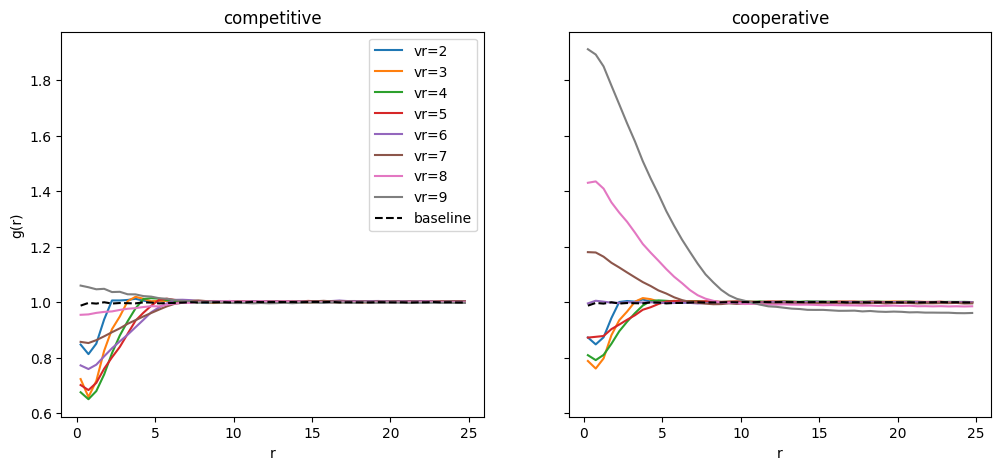

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

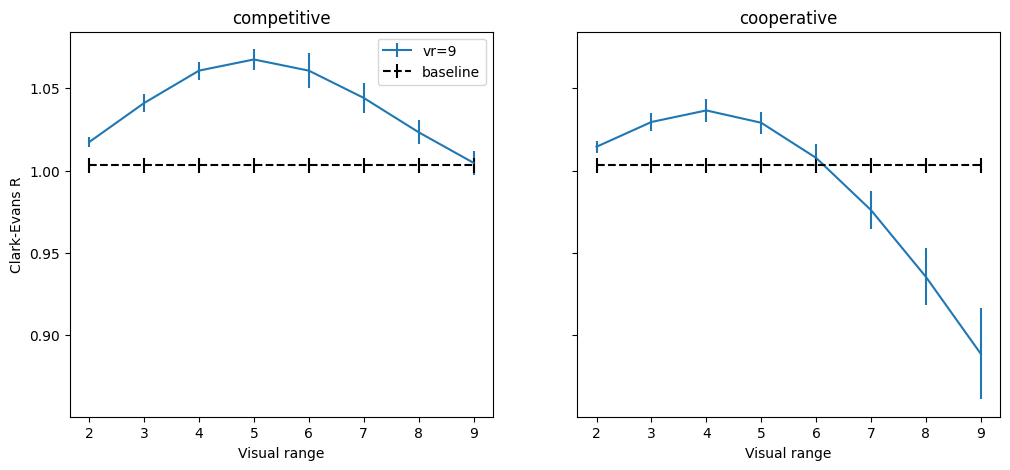

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')
ax[1].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

#### Episodes = 10k

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

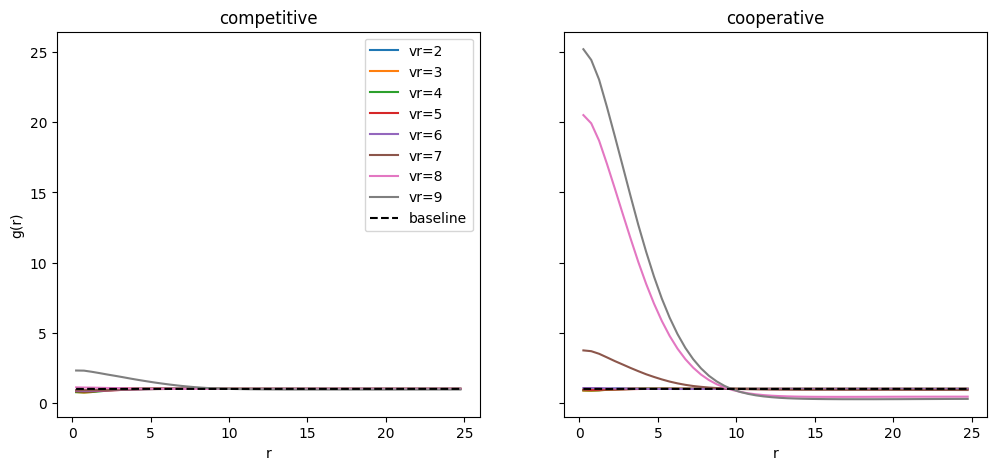

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, visual_range in enumerate(visual_ranges):
        ax[idx_sd].plot(r_c, grs[idx_sd, :, idx_vr].mean(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, 'Visual range'), Text(0.5, 0, 'Visual range')]

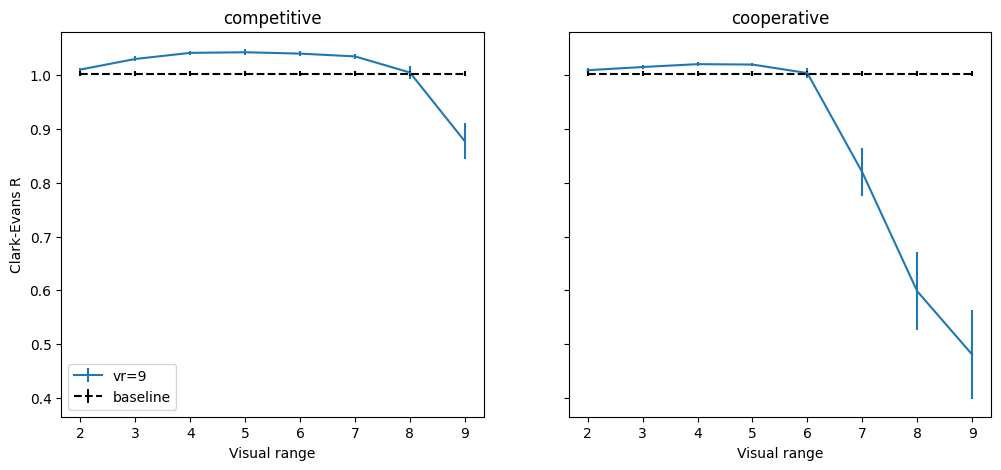

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(visual_ranges, cr_idx[idx_sd].mean(0), yerr=cr_idx[idx_sd].std(0), label=f"vr={visual_range}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')
ax[1].errorbar(visual_ranges, np.ones_like(visual_ranges) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = "Visual range")

## EXP 7_1 - tau_r

In [ ]:
from rl_opts.rl_framework.numba.agents import Foragers_efficient, run_collective
from rl_opts.rl_framework.numba.environments import CollectiveEnv
import numba
import os
import numpy as np

# Change for this run:
taus_reward = np.arange(2, 11, 1)-1 # See comment in EXP_7
visual_range = 4

num_agents = 50
max_counter = 50
runs = 1

Nt = 100; L = 50; r = 0.5
agent_step = 1
tau = 2
visual_activated = True
visual_angle=np.pi / 2 # Note that this is from the center, so from +45 to -45

# State space: [counter, any_agent_in_cone (0/1), rewarded_agent_in_cone (0/1)]
state_space = np.array([max_counter, 2, 2])

time_ep = 5000
episodes = 2000

if os.getlogin() == "gorka":
    if socket.gethostname() == "gpu-qic":
        out_dir = "/media/gorka/DATA/rl_opts_data/results_learning/collective/"
    elif socket.gethostname() == "gpu-ada-qic":
        out_dir = "/home/gorka/rl_opts/nbs/lib_nbs/develop/results/"
elif os.getlogin() == "c7051165":
    out_dir = "/scratch/c7051165/github/rl_opts/nbs/lib_nbs/develop/results/"
out_dir = os.path.join(out_dir, f"exp_7_1")
out_dir

'/media/gorka/DATA/rl_opts_data/results_learning/collective/exp_7_1'

In [ ]:
episodes = 1
time_ep = 10000
save_position_from_ep = 7500

# Loading for getting runs
file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{taus_reward[0]+1}_vr_{visual_range}_ep_2000.npy"                           
h_matrix_path = os.path.join(out_dir, f"h_matrix"+file_name)
runs = np.load(h_matrix_path).shape[0]


dr = 0.5
n_bins = int(L / 2 / dr)
grs_tau = np.zeros((2, runs, len(taus_reward), n_bins))
cr_idx_tau = np.zeros((2, runs, len(taus_reward)))
for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate(tqdm(taus_reward)):

        file_name = f"_shared_{shared_depletion}_tau_{tau}_tauR_{tau_reward+1}_vr_{visual_range}_ep_2000.npy"
                            
        h_matrix_path = os.path.join(out_dir, 
                                    f"h_matrix"+file_name)
        try:
            mats = np.load(h_matrix_path)
        except:
            continue

        rews, posr = run_simul_collective(episodes = episodes, time_ep = time_ep, runs = runs, h_0= mats, initial_h_0=True,
                                          Nt = Nt, L = L, r = r, tau = tau, agent_step = agent_step, num_agents = num_agents,
                                    visual_range = visual_range, visual_angle = visual_angle, 
                                    shared_depletion = shared_depletion, tau_reward = tau_reward, upd_pos_method = 'RND', turn_angle = visual_angle,
                                    save_position_from_ep = save_position_from_ep)        
        
        r_c, gr_runs, cr_runs = compute_gr_all_runs(posr, L=L, dr=0.5)
        grs_tau[idx_sd, :, idx_vr, :] = gr_runs
        cr_idx_tau[idx_sd, :, idx_vr] = cr_runs

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

[Text(0.5, 0, 'r'), Text(0.5, 0, 'r')]

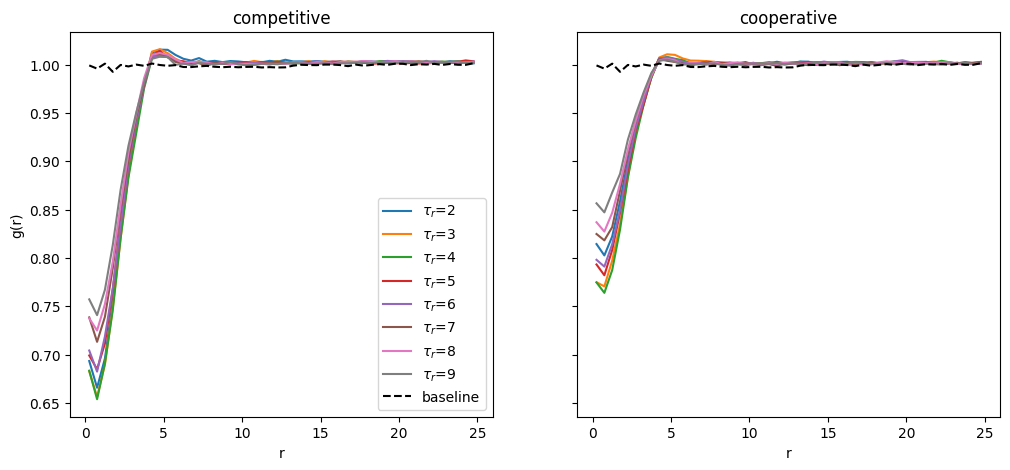

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
    for idx_vr, tau_reward in enumerate((taus_reward[:-1])):
        ax[idx_sd].plot(r_c, grs_tau[idx_sd, :, idx_vr].mean(0), label=fr"$\tau_r$={tau_reward+1}")
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

for i in  [0,1]:
    ax[i].plot(r_c, np.array(gr_baseline).mean(0), label="baseline", color='black', linestyle='--')

ax[0].legend()
ax[0].set_ylabel("g(r)")
plt.setp(ax, xlabel = "r")

[Text(0.5, 0, '$\\tau_r$'), Text(0.5, 0, '$\\tau_r$')]

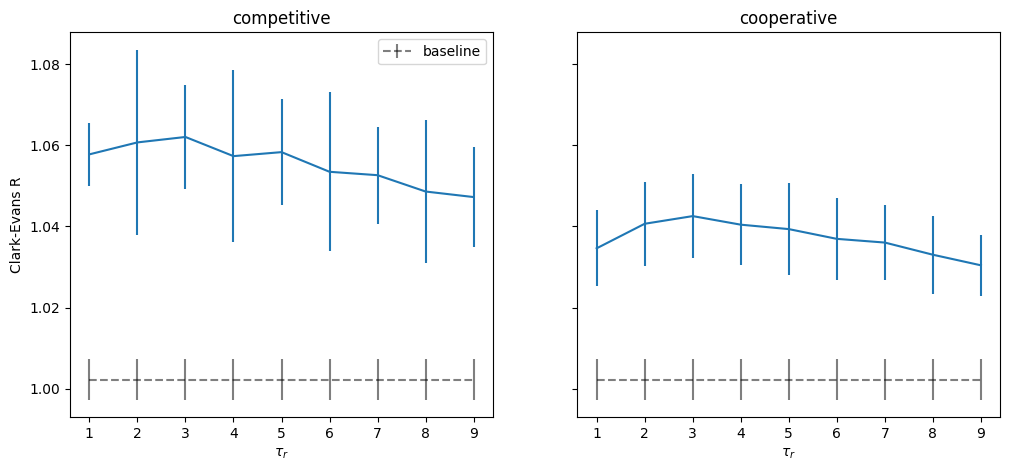

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(12,5), sharey=True)

for idx_sd, shared_depletion in enumerate([True, False]):
        
    ax[idx_sd].errorbar(taus_reward, cr_idx_tau[idx_sd].mean(0), yerr=cr_idx_tau[idx_sd].std(0))
    title = 'competitive' if shared_depletion else 'cooperative'
    ax[idx_sd].set_title(title)

ax[0].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--', alpha = 0.5)
ax[1].errorbar(taus_reward, np.ones_like(taus_reward) * np.array(cr_baseline).mean(0), yerr=np.array(cr_baseline).std(0), label="baseline", color='black', linestyle='--', alpha = 0.5)

ax[0].legend()
ax[0].set_ylabel("Clark-Evans R")
plt.setp(ax, xlabel = r"$\tau_r$")

In [ ]:
4*5*2*3 / 24

5.0